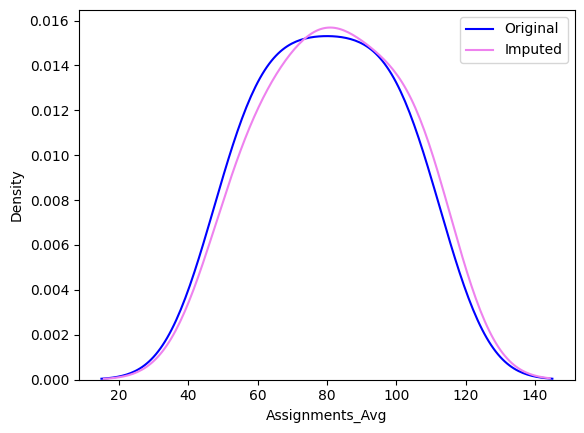

Predictions on test set:
[1 0 1]


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

# Custom Random Imputer class
class RandomImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        # Store the valid values for each column
        self.valid_values_ = {}
        for col in X.columns:
            self.valid_values_[col] = X[col].dropna().values
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col in X_copy.columns:
            mask = X_copy[col].isna()
            if mask.sum() > 0:  # If there are missing values
                X_copy.loc[mask, col] = np.random.choice(self.valid_values_[col], size=mask.sum())
        return X_copy

# Sample data
data = {'Assignments_Avg': [50, 60, np.nan, 70, 80, 90, np.nan, 100, 110, 55, 65, 75, 85, 95, 105],
        'Feature2': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]}
df = pd.DataFrame(data)
y = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

# Create a copy for imputation
df_encod = df.copy()

# Apply the custom random imputer
imputer = RandomImputer()
df_encod = imputer.fit_transform(df_encod)

# Plot the kernel density plots to compare
sns.kdeplot(df['Assignments_Avg'], label='Original', color='blue')
sns.kdeplot(df_encod['Assignments_Avg'], label='Imputed', color='violet')
plt.legend()
plt.xlabel('Assignments_Avg')
plt.ylabel('Density')
plt.show()

# Split the data for training and testing
X = df_encod[['Assignments_Avg', 'Feature2']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model and make predictions
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Print the predictions
print("Predictions on test set:")
print(predictions)